# Analiza taktične revolucije v ligi NBA (2000–2025)

Od leta 2000 je NBA doživel eno največjih taktičnih sprememb v zgodovini športnih analiz (t.i. *Moreyball* revolucija). Glavna vprašanje te analize so:
1. Koliko se je povečalo število metov za 3 točke in kako je to vplivalo na met za 2 točki?
2. Ali ekipe, ki zmagajo sezono, vržejo več trojk ali so le bolj natančne?
3. Ali je povečanje količine metov vplivalo na padanje odstotka zadetkov?

In [14]:
%pip install matplotlib
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("nba_popolna_statistika.csv")
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("--- PRVIH 5 VRSTIC TABELE ---")
display(df.head())

print("\n--- INFORMACIJE O STOLPCIḤ ---")
df.info()

Note: you may need to restart the kernel to use updated packages.
--- PRVIH 5 VRSTIC TABELE ---



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,Leto,Zmagovalna_ekipa,Liga_poskusi_3p,Liga_zadetki_3p,Liga_odstotek_3p,Liga_poskusi_2p,Liga_zadetki_2p,Liga_odstotek_2p,Liga_poskusi_PM,Liga_zadetki_PM,Liga_odstotek_PM,Prvak_poskusi_3p,Prvak_zadetki_3p,Prvak_odstotek_3p,Prvak_poskusi_2p,Prvak_zadetki_2p,Prvak_odstotek_2p,Prvak_poskusi_PM,Prvak_zadetki_PM,Prvak_odstotek_PM
0,2000,Los Angeles Lakers,13.7,4.8,0.353,68.4,32.0,0.468,25.3,19.0,0.750,12.8,4.2,0.329,70.6,34.1,0.482,28.9,20.1,0.696
1,2001,Los Angeles Lakers,13.7,4.8,0.354,66.9,30.8,0.461,24.9,18.6,0.748,15.5,5.4,0.344,66.0,32.6,0.494,28.5,19.4,0.683
2,2002,Los Angeles Lakers,14.7,5.2,0.354,66.5,31.0,0.465,23.8,17.9,0.752,17.5,6.2,0.354,65.9,32.2,0.489,26.1,18.2,0.699
3,2003,San Antonio Spurs,14.7,5.1,0.349,66.1,30.6,0.463,24.4,18.5,0.758,15.5,5.5,0.354,61.3,30.0,0.489,26.8,19.4,0.725
4,2004,Detroit Pistons,14.9,5.2,0.347,64.9,29.8,0.460,24.2,18.2,0.752,11.8,4.1,0.344,65.2,29.4,0.452,25.3,19.0,0.753



--- INFORMACIJE O STOLPCIḤ ---
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Leto               26 non-null     int64  
 1   Zmagovalna_ekipa   26 non-null     str    
 2   Liga_poskusi_3p    26 non-null     float64
 3   Liga_zadetki_3p    26 non-null     float64
 4   Liga_odstotek_3p   26 non-null     float64
 5   Liga_poskusi_2p    26 non-null     float64
 6   Liga_zadetki_2p    26 non-null     float64
 7   Liga_odstotek_2p   26 non-null     float64
 8   Liga_poskusi_PM    26 non-null     float64
 9   Liga_zadetki_PM    26 non-null     float64
 10  Liga_odstotek_PM   26 non-null     float64
 11  Prvak_poskusi_3p   26 non-null     float64
 12  Prvak_zadetki_3p   26 non-null     float64
 13  Prvak_odstotek_3p  26 non-null     float64
 14  Prvak_poskusi_2p   26 non-null     float64
 15  Prvak_zadetki_2p   26 non-null     float64
 16  Prvak_o

---
## 1. Sprememba načina igre: Dvojke vs. Trojke
V tem delu bomo preučili spremembe v količinah metov ter primerjali razliko med povprečjem celotne lige ter zmagovalcev sezone.

### Ključne ugotovitve (Graf 1 & 2):
> Število poskusov za 3 točke se je iz leta 2000 (13.7 poskusov na tekmo) v leto 2025 (preko 37 poskusov na tekmo) **skoraj potrojilo**.
> Število metov za 2 točki postopoma pada, kar potrjuje premik igre od koša proti zunanji liniji.
> Zmagovalci sezon (npr. Golden State Warriors 2015/2017 ali Boston Celtics 2024) so bili pogosto med pionirji zviševanja volumna metov za 3 točke.

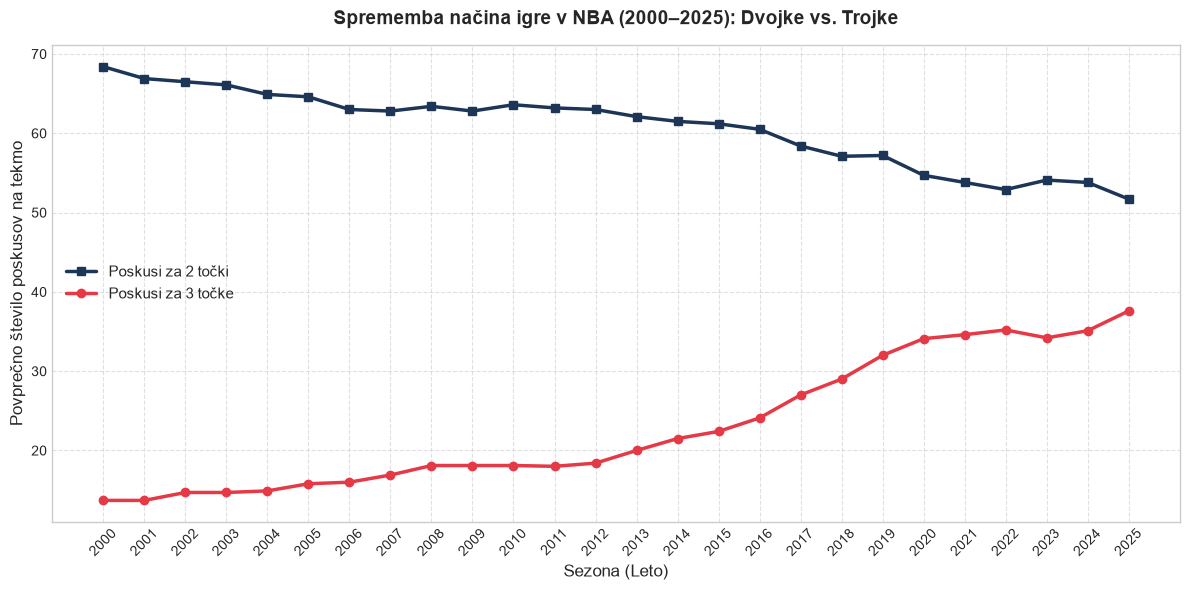

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(df['Leto'], df['Liga_poskusi_2p'], marker='s', color='#1D3557', linewidth=2.5, label='Poskusi za 2 točki')
plt.plot(df['Leto'], df['Liga_poskusi_3p'], marker='o', color='#E63946', linewidth=2.5, label='Poskusi za 3 točke')

plt.title('Sprememba načina igre v NBA (2000–2025): Dvojke vs. Trojke', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sezona (Leto)', fontsize=12)
plt.ylabel('Povprečno število poskusov na tekmo', fontsize=12)

plt.xticks(df['Leto'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='center left')

plt.tight_layout()
plt.show()

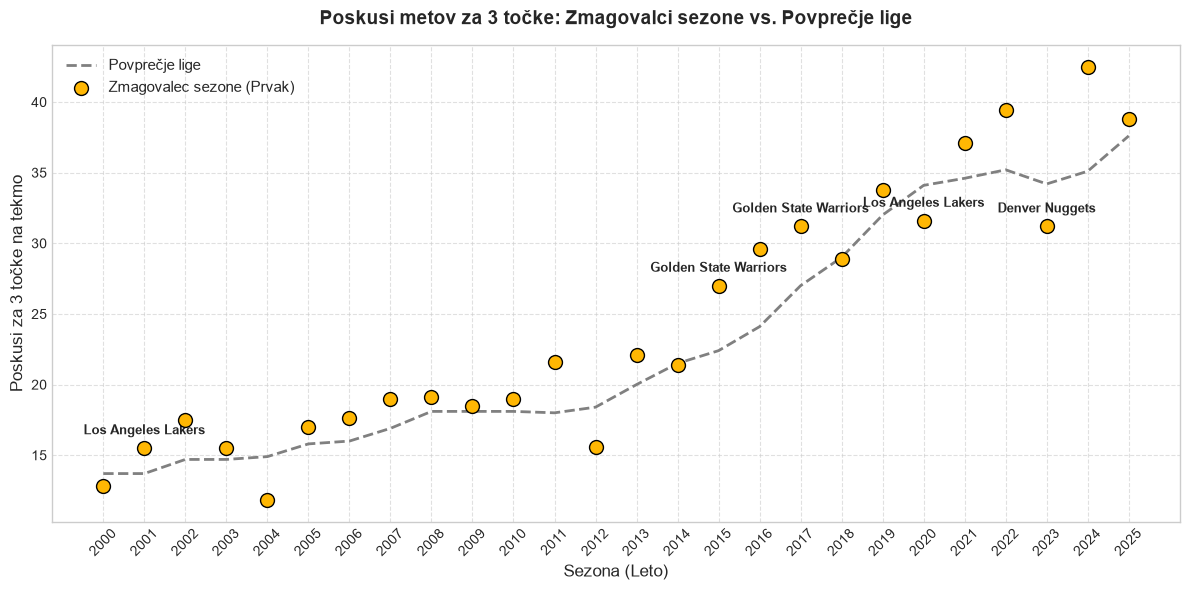

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df['Leto'], df['Liga_poskusi_3p'], color='gray', linestyle='--', linewidth=2, label='Povprečje lige')

df_prvaki = df.dropna(subset=['Prvak_poskusi_3p'])
plt.scatter(df_prvaki['Leto'], df_prvaki['Prvak_poskusi_3p'], color='#FFB703', s=100, edgecolor='black', zorder=5, label='Zmagovalec sezone (Prvak)')

za_izpis = [2001, 2015, 2017, 2020, 2024]
for idx, row in df_prvaki.iterrows():
    if row['Leto'] in za_izpis:
        plt.annotate(row['Zmagovalna_ekipa'], 
                     (row['Leto'], row['Prvak_poskusi_3p']),
                     textcoords="offset points", 
                     xytext=(0,10), 
                     ha='center', fontsize=9, fontweight='bold')

plt.title('Poskusi metov za 3 točke: Zmagovalci sezone vs. Povprečje lige', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sezona (Leto)', fontsize=12)
plt.ylabel('Poskusi za 3 točke na tekmo', fontsize=12)

plt.xticks(df['Leto'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

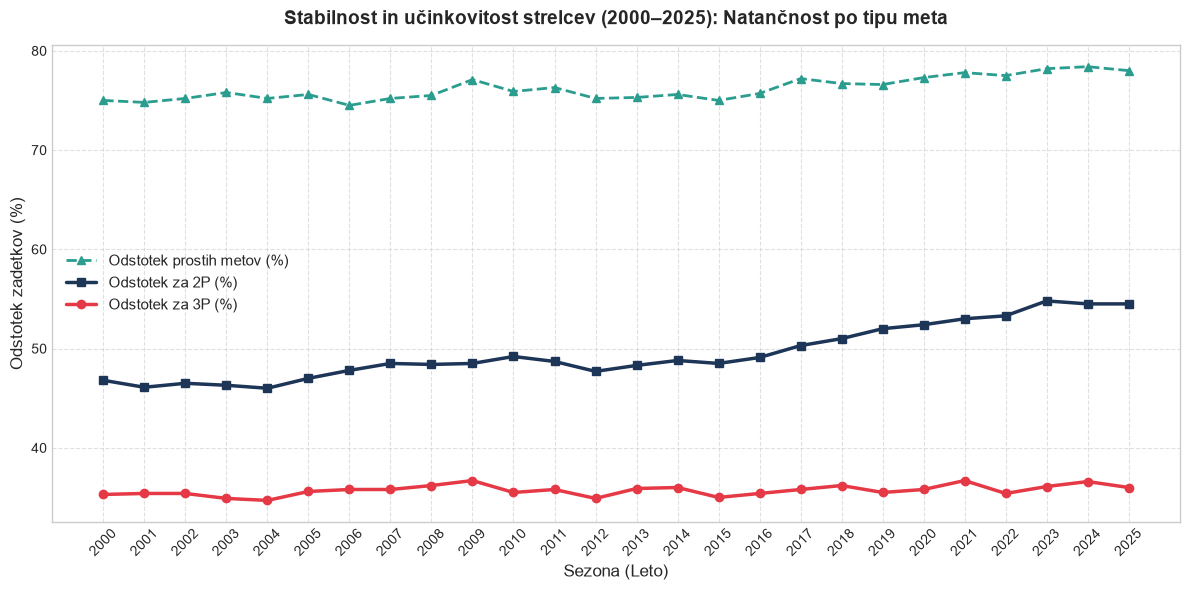

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(df['Leto'], df['Liga_odstotek_PM'] * 100, marker='^', color='#2A9D8F', linewidth=2, linestyle='--', label='Odstotek prostih metov (%)')
plt.plot(df['Leto'], df['Liga_odstotek_2p'] * 100, marker='s', color='#1D3557', linewidth=2.5, label='Odstotek za 2P (%)')
plt.plot(df['Leto'], df['Liga_odstotek_3p'] * 100, marker='o', color='#E63946', linewidth=2.5, label='Odstotek za 3P (%)')

plt.title('Stabilnost in učinkovitost strelcev (2000–2025): Natančnost po tipu meta', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sezona (Leto)', fontsize=12)
plt.ylabel('Odstotek zadetkov (%)', fontsize=12)

plt.xticks(df['Leto'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

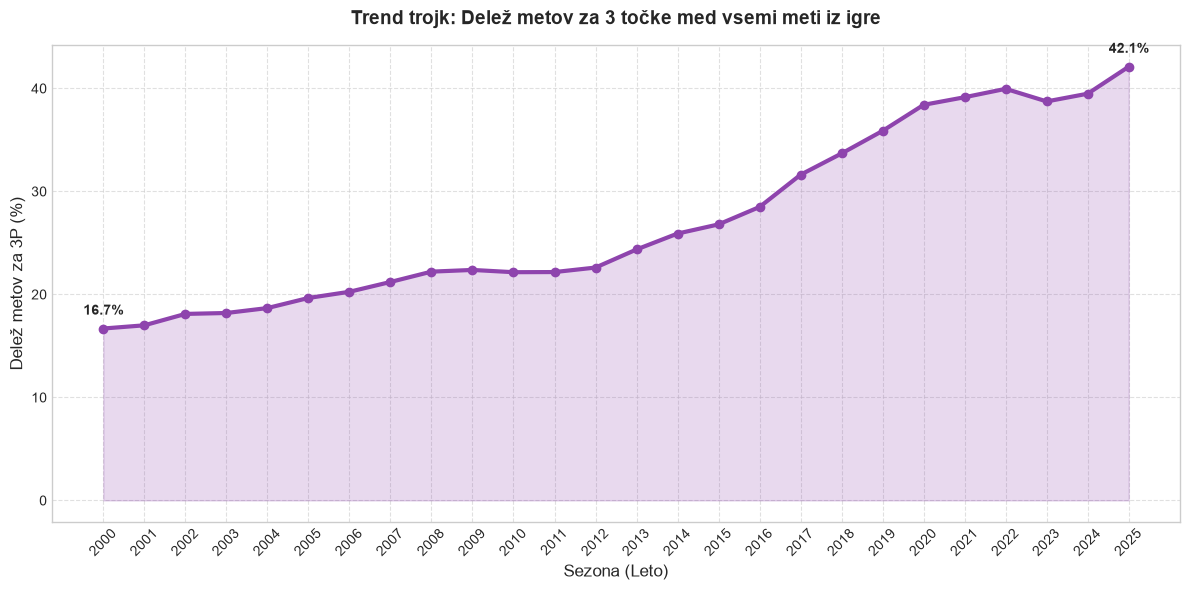

In [25]:
plt.figure(figsize=(12, 6))

vsi_meti = df['Liga_poskusi_3p'] + df['Liga_poskusi_2p']
delez_3p = (df['Liga_poskusi_3p'] / vsi_meti) * 100

plt.plot(df['Leto'], delez_3p, marker='o', color='#8E44AD', linewidth=3)
plt.fill_between(df['Leto'], delez_3p, color='#8E44AD', alpha=0.2) 

plt.title('Trend trojk: Delež metov za 3 točke med vsemi meti iz igre', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sezona (Leto)', fontsize=12)
plt.ylabel('Delež metov za 3P (%)', fontsize=12)

plt.annotate(f"{delez_3p.iloc[0]:.1f}%", (df['Leto'].iloc[0], delez_3p.iloc[0]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')
plt.annotate(f"{delez_3p.iloc[-1]:.1f}%", (df['Leto'].iloc[-1], delez_3p.iloc[-1]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.xticks(df['Leto'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

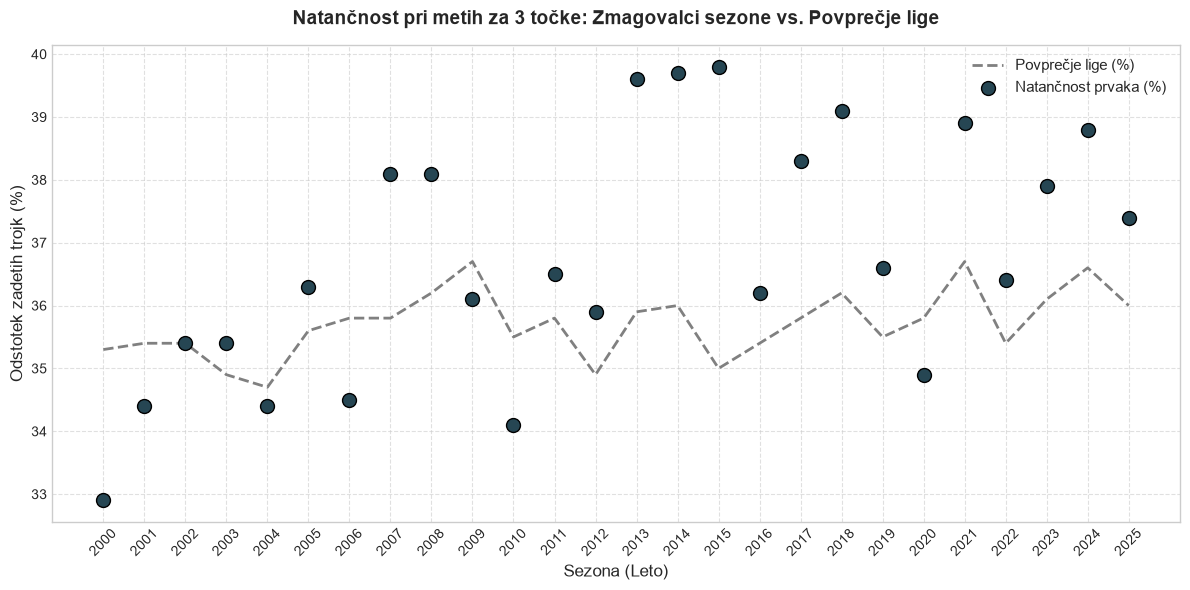

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(df['Leto'], df['Liga_odstotek_3p'] * 100, color='gray', linestyle='--', linewidth=2, label='Povprečje lige (%)')

df_prvaki = df.dropna(subset=['Prvak_odstotek_3p'])
plt.scatter(df_prvaki['Leto'], df_prvaki['Prvak_odstotek_3p'] * 100, color='#264653', s=100, edgecolor='black', zorder=5, label='Natančnost prvaka (%)')

plt.title('Natančnost pri metih za 3 točke: Zmagovalci sezone vs. Povprečje lige', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sezona (Leto)', fontsize=12)
plt.ylabel('Odstotek zadetih trojk (%)', fontsize=12)

plt.xticks(df['Leto'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## Končne ugotovitve

Na podlagi zbranih podatkov in njihove analize iz let 2000–2025 je jasno razvidno, da je met za 3 točke veliko bolj pomemben in pogost v sedanjosti lige NBA. Ekipa, ki želi postati zmagovalka sezone NBA, mora imeti ne le veliko število poskusov za 3 točke ampak tudi zelo visoko natančnost meta za 3 točke. Grafi jasno kažejo, da mora biti 1. prioriteta v napadu ustvarjanje čim lepših priložnosti za met iz črte za 3 točke.